   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
Cluster Counts:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64

Cluster Centers:
[[-0.05021989 -0.88029181  0.34753171  0.28206327]
 [-1.01457897  0.84230679 -1.30487835 -1.25512862]
 [ 1.13597027  0.09659843  0.996271    1.01717187]]


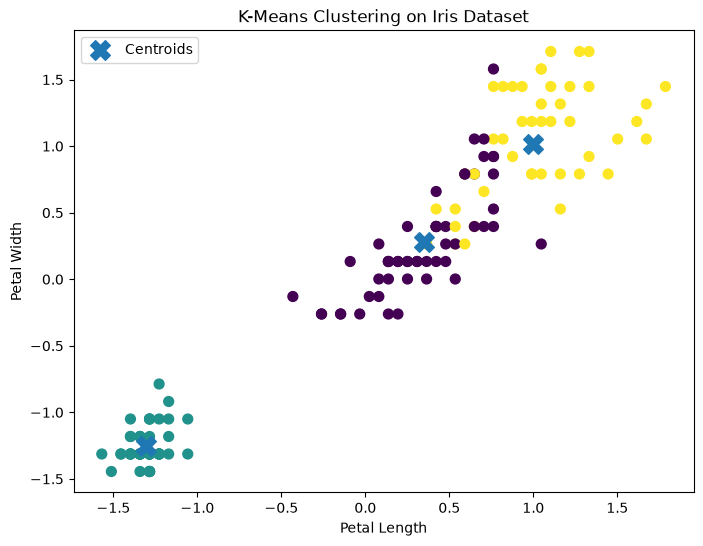

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df = pd.read_csv(url, names=columns)

print(df.head())

# Select numerical features
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create K-Means model with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train the model and assign clusters
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Display cluster information
print("Cluster Counts:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# Visualize the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=df["Cluster"],
    s=50
)

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 2],
    kmeans.cluster_centers_[:, 3],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()
plt.show()